In [3]:
import os
os.listdir('../data')

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data'

In [4]:
os.listdir()

['.ipynb_checkpoints',
 'anaconda_projects',
 'app.py.txt',
 'data',
 'models',
 'notebooks',
 'src',
 'Untitled.ipynb']

In [6]:
os.listdir('../data')

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data'

In [7]:
os.listdir('data')

['spam.csv']

In [8]:
import pandas as pd

df = pd.read_csv('data/spam.csv')

df.head()

UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 606-607: invalid continuation byte

In [9]:
import pandas as pd

df = pd.read_csv('data/spam.csv', encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [10]:
df.shape
df['label'].value_counts()

KeyError: 'label'

In [11]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df.shape
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [13]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_42676\1776796882.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['label'].map({'ham': 0, 'spam': 1})


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df = df.copy()
df.loc[:, 'label'] = df['label'].map({'ham': 0, 'spam': 1})


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_42676\1257160189.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan nan nan ... nan nan nan]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'label'] = df['label'].map({'ham': 0, 'spam': 1})


In [15]:
df.isnull().sum()

label      5572
message       0
dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', MultinomialNB())
])

model.fit(X_train, y_train)

ValueError: Input y contains NaN.

In [18]:
import numpy as np
import pandas as pd

In [19]:
df = pd.read_csv('spam.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'spam.csv'

In [20]:
df.sample(5)


,label,message
3699,NaN,Oh...i asked for fun. Haha...take care. Ì_
3664,NaN,Ha... U jus ate honey ar? So sweet...
3514,NaN,I'm job profile seems like bpo..
494,NaN,Are you free now?can i call now?
892,NaN,Nutter. Cutter. Ctter. Cttergg. Cttargg. Ctarg...


In [21]:
df.shape

(5572, 2)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   label    0 non-null      float64
 1   message  5572 non-null   object 
dtypes: float64(1), object(1)
memory usage: 87.2+ KB


In [23]:
df.sample(5)


,label,message
952,NaN,Beautiful Truth against Gravity.. Read careful...
4631,NaN,"I'm in a meeting, call me later at"
1561,NaN,Dnt worry...use ice pieces in a cloth pack.als...
853,NaN,\AH POOR BABY!HOPE URFEELING BETTERSN LUV! PRO...
3506,NaN,Two fundamentals of cool life: \Walk


In [24]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,label,message
3786,NaN,WHORE YOU ARE UNBELIEVABLE.
3174,NaN,UR GOING 2 BAHAMAS! CallFREEFONE 08081560665 a...
4577,NaN,Urgent! call 09066350750 from your landline. Y...
1899,NaN,I love working from home :)
766,NaN,"I'm nt goin, got somethin on, unless they meet..."


In [25]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [26]:
df['text']

KeyError: 'text'

In [27]:
encoder.fit_transform(df['target'])

KeyError: 'target'

# Assistant
This error occurs because the DataFrame `df` does not have a column named 'target'. The KeyError indicates that you're trying to access a key (column name) that doesn't exist in the DataFrame.

Would you like me to provide the corrected code?

In [29]:
df['label']=encoder.fit_transform(df['label'])

In [30]:
df.head()


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,0,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [31]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(403)

In [34]:
df = df.drop_duplicates(keep='first')

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.shape

(5169, 2)

In [37]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,0,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [39]:
df['label'].value_counts()

label
0    5169
Name: count, dtype: int64

ValueError: 'labels' must be of length 'x', not 2

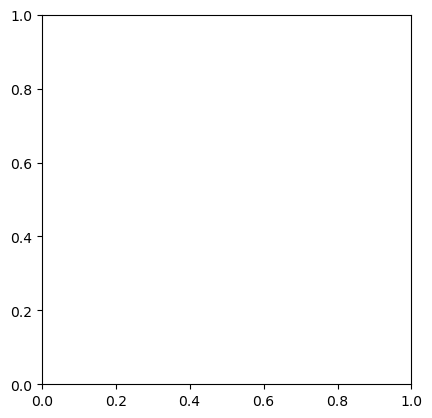

In [40]:
import matplotlib.pyplot as plt
plt.pie(df['label'].value_counts(), labels=['ham','spam'],autopct="%0.2f")

ValueError: 'labels' must be of length 'x', not 2

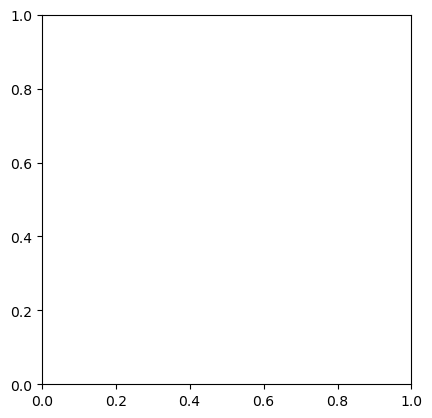

In [41]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts()

plt.pie(counts,
        labels=['ham', 'spam'],
        autopct='%1.2f%%')

plt.title("Spam vs Ham Distribution")
plt.show()

In [42]:
df['label'].unique()

array([0])

In [43]:
# Reload dataset fresh
df = pd.read_csv('data/spam.csv', encoding='latin-1')

# Keep only needed columns
df = df[['v1', 'v2']]

# Rename properly
df.columns = ['label', 'message']

# Now convert labels
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

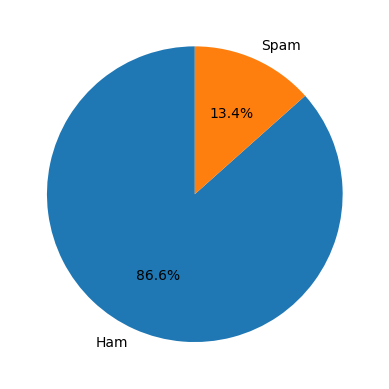

In [44]:
counts = df['label'].value_counts()

plt.pie(counts,
        labels=['Ham', 'Spam'],
        autopct='%1.1f%%',
        startangle=90)

plt.show()

In [45]:
import nltk


In [47]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [48]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [54]:
df['num_characters'] = df['message'].apply(len)

In [55]:
df.head()

,label,message,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [60]:
df['message'].apply(lambda x:nltk.word_tokenize(x))

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\KIIT0001/nltk_data'
    - 'C:\\Users\\KIIT0001\\anaconda3\\nltk_data'
    - 'C:\\Users\\KIIT0001\\anaconda3\\share\\nltk_data'
    - 'C:\\Users\\KIIT0001\\anaconda3\\lib\\nltk_data'
    - 'C:\\Users\\KIIT0001\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [59]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [61]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [64]:
import nltk

df['num_words']=df['message'].apply(lambda x: len(nltk.word_tokenize(x)))

In [65]:
df.head()

,label,message,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [66]:
df['num_sentences']=df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [67]:
df.head()

,label,message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [68]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5572.000000,5572.000000,5572.000000
mean,80.118808,18.699390,1.996411
std,59.690841,13.741932,1.520159
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.500000
75%,121.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


In [72]:
df[df['label']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4825.000000,4825.000000,4825.000000
mean,71.023627,17.276269,1.837720
std,58.016023,13.988585,1.454388
min,2.000000,1.000000,1.000000
25%,33.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,92.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [74]:
df[df['label']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,747.000000,747.000000,747.000000
mean,138.866131,27.891566,3.021419
std,29.183082,6.867007,1.537580
min,13.000000,2.000000,1.000000
25%,132.500000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [75]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

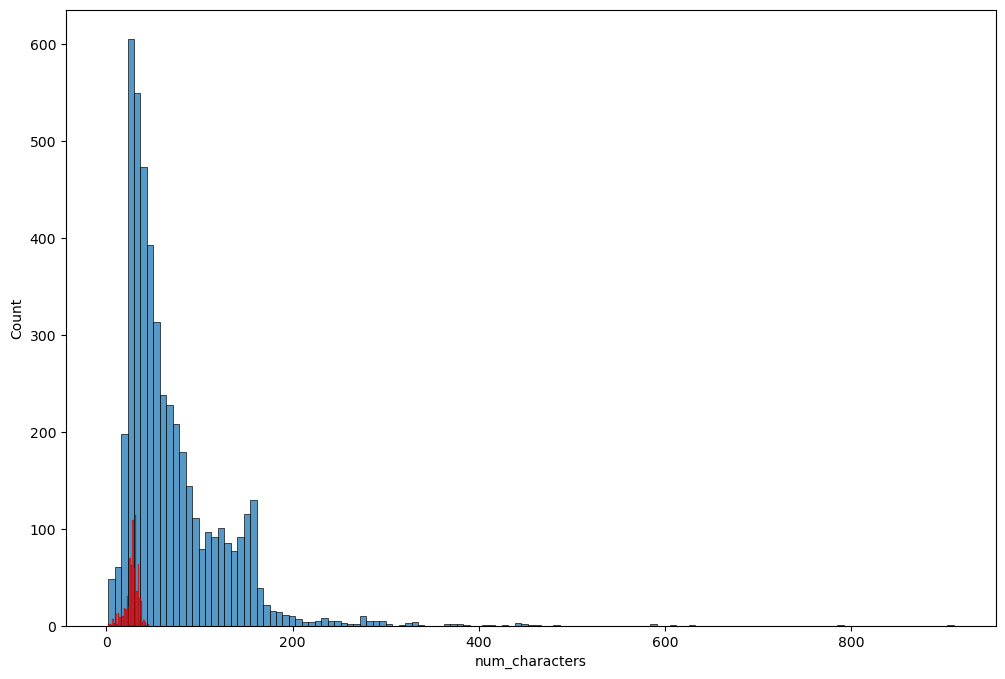

In [80]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['label']==0]['num_characters'])
sns.histplot(df[df['label']==1]['num_words'],color='red')

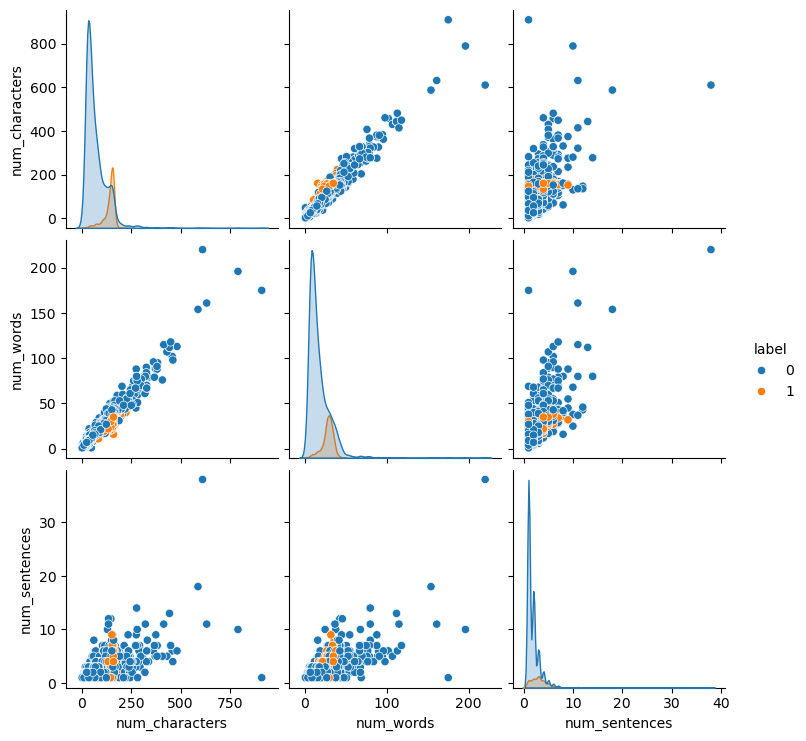

In [81]:
sns.pairplot(df,hue='label')

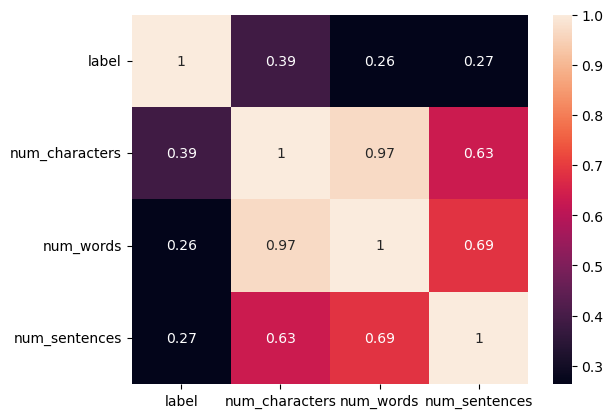

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [114]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text= y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [107]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [108]:
from nltk.corpus import stopwords

stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [109]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [110]:
transform_text('Hi how Are you')

['hi']

In [111]:
df['message'][2000]

"But i'll b going 2 sch on mon. My sis need 2 take smth."

In [112]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [119]:
df['transformed_text']= df['message'].apply(transform_text)

In [120]:
df.head()

,label,message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [123]:
!pip install wordcloud

In [124]:
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [126]:
spam_wc = wc.generate(df[df['label'] == 1]['transformed_text'].str.cat(sep=" "))

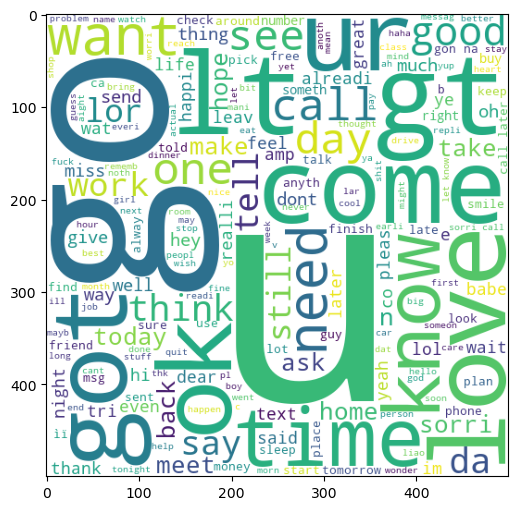

In [130]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [129]:
ham_wc = wc.generate(df[df['label'] == 0]['transformed_text'].str.cat(sep=" "))

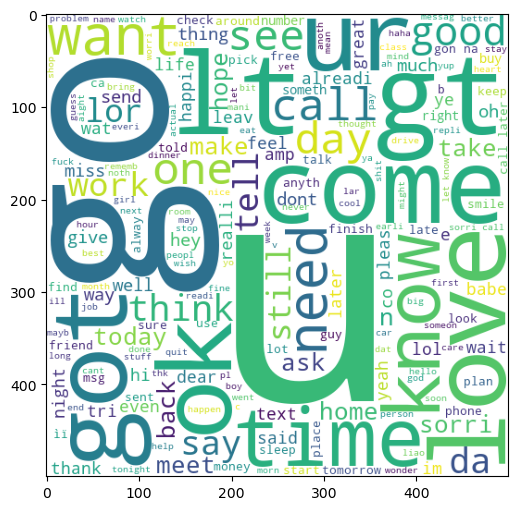

In [131]:
plt.figure(figsize=(12,6))
plt.imshow(ham_wc)

In [132]:
df.head()

,label,message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [137]:
spam_corpus = []
for msg in df[df['label'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
    

In [138]:
len(spam_corpus)

11490

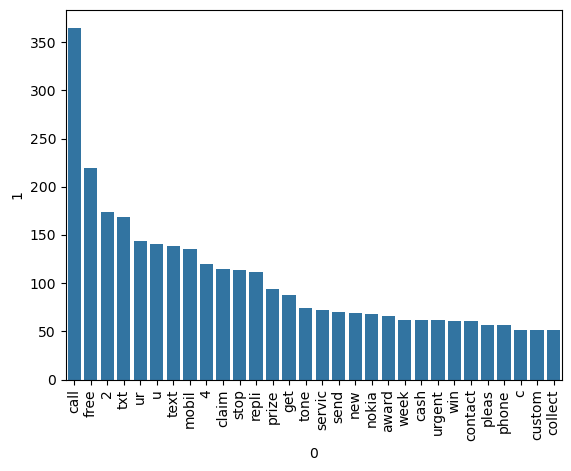

In [142]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

top_words = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=top_words[0], y=top_words[1])
plt.xticks(rotation=90)
plt.show()

In [143]:
ham_corpus = []
for msg in df[df['label'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
    

In [144]:
len(ham_corpus)

38221

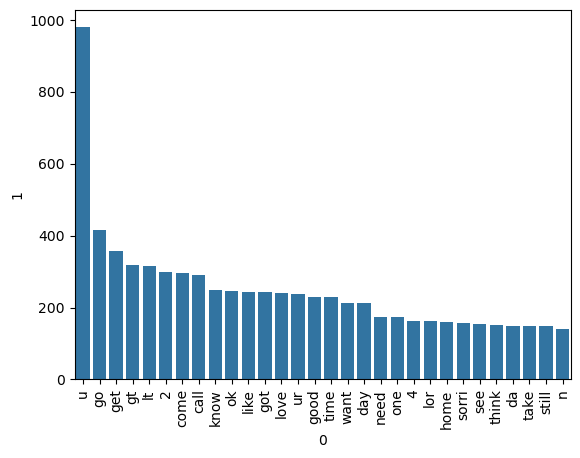

In [145]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

top_words = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=top_words[0], y=top_words[1])
plt.xticks(rotation=90)
plt.show()

In [159]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [162]:
x=tfidf.fit_transform(df['transformed_text']).toarray()

In [163]:
x.shape

(5572, 6708)

In [164]:
y = df['label'].values

In [165]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [166]:
from sklearn.model_selection import train_test_split

In [167]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=2)

In [168]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score

In [169]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [158]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8584229390681004
[[423  67]
 [ 12  56]]
0.45528455284552843


In [173]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.956989247311828
[[490   0]
 [ 24  44]]
1.0


In [174]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.974910394265233
[[489   1]
 [ 13  55]]
0.9821428571428571


In [175]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'xgboost'

In [176]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 2.6 MB/s eta 0:00:39
    --------------------------------------- 2.1/101.7 MB 3.3 MB/s eta 0:00:31
    --------------------------------------- 2.4/101.7 MB 2.6 MB/s eta 0:00:39
   - -------------------------------------- 2.6/101.7 MB 2.4 MB/s eta 0:00:41
   - -------------------------------------- 3.7/101.7 MB 2.7 MB/s eta 0:00:37
   - -------------------------------------- 5.0/101.7 MB 3.2 MB/s eta 0:00:31
   -- ------------------------------------- 6.3/101.7 MB 3.5 MB/s eta 0:00:28
   -- ------------------------------------- 7.3/101.7 MB 3.7 MB/s eta 0:00:26
   --- ------------------------------------ 8.7/101.7 MB 3.9 MB/s eta 0:00:24
   --- ------------------------------------ 10.0/101.7 MB 4.1 MB/s eta 0:00:23
   ---

In [177]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [178]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [179]:
clfs = {
    'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [182]:
def train_classifier(clf, x_train, y_train, x_test, y_test):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    return accuracy, precision

In [184]:
train_classifier(svc, x_train, y_train, x_test, y_test)

(0.9713261648745519, 0.9814814814814815)

In [186]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    
    current_accuracy, current_precision = train_classifier(
        clf, x_train, y_train, x_test, y_test
    )
    
    print("For", name)
    print("Accuracy:", current_accuracy)
    print("Precision:", current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC
Accuracy: 0.9713261648745519
Precision: 0.9814814814814815
For KN
Accuracy: 0.9175627240143369
Precision: 1.0
For NB
Accuracy: 0.956989247311828
Precision: 1.0
For DT
Accuracy: 0.931899641577061
Precision: 0.875
For LR
Accuracy: 0.9551971326164874
Precision: 0.9777777777777777
For RF
Accuracy: 0.9713261648745519
Precision: 1.0
For AdaBoost
Accuracy: 0.9265232974910395
Precision: 0.9090909090909091
For BgC
Accuracy: 0.974910394265233
Precision: 0.95
For ETC
Accuracy: 0.9767025089605734
Precision: 1.0
For GBDT
Accuracy: 0.9480286738351255
Precision: 0.975609756097561
For xgb
Accuracy: 0.9713261648745519
Precision: 0.9642857142857143


In [195]:
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
}).sort_values('Accuracy',ascending=False)

performance_df

,Algorithm,Accuracy,Precision
8,ETC,0.976703,1.000000
7,BgC,0.974910,0.950000
0,SVC,0.971326,0.981481
5,RF,0.971326,1.000000
10,xgb,0.971326,0.964286
2,NB,0.956989,1.000000
4,LR,0.955197,0.977778
9,GBDT,0.948029,0.975610
3,DT,0.931900,0.875000
6,AdaBoost,0.926523,0.909091


In [192]:
performance_df1=pd.melt(performance_df,id_vars="Algorithm")

In [194]:
performance_df1

,Algorithm,variable,value
0,SVC,Accuracy,0.971326
1,KN,Accuracy,0.917563
2,NB,Accuracy,0.956989
3,DT,Accuracy,0.931900
4,LR,Accuracy,0.955197
5,RF,Accuracy,0.971326
6,AdaBoost,Accuracy,0.926523
7,BgC,Accuracy,0.974910
8,ETC,Accuracy,0.976703
9,GBDT,Accuracy,0.948029


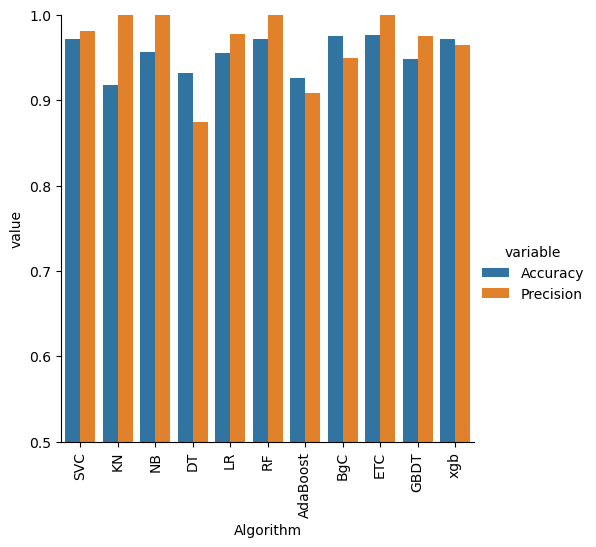

In [196]:
sns.catplot(
    x='Algorithm',
    y='value',
    hue='variable',
    data=performance_df1,
    kind='bar',
    height=5
)

plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.show()

In [197]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))